In [1]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Bio import SeqIO

import SBM.utils.utils as ut

In [2]:
entries = []

for model_folder in glob.glob("../models/SectorShuffling_SubAln*"):
    subaln_index = int(model_folder.split("_")[1][6:])
    step_index = model_folder.split("_")[2][4:]
    step_index = int(step_index)

    print(model_folder)
    
    model_file = glob.glob(model_folder + "/*.npy")[0]
    entry = {
        'subaln_index': subaln_index,
        'step_index': step_index,
        'model_file': model_file
    }
    entries.append(entry)
    
df = pd.DataFrame(entries).sort_values(["step_index", "subaln_index"]).set_index(["step_index", "subaln_index"])

../models/SectorShuffling_SubAln0_Step10_Col229
../models/SectorShuffling_SubAln6_Step10_Col229
../models/SectorShuffling_SubAln6_Step22_Col239
../models/SectorShuffling_SubAln3_Step00_noshuffle
../models/SectorShuffling_SubAln1_Step00_noshuffle
../models/SectorShuffling_SubAln5_Step20_Col237
../models/SectorShuffling_SubAln0_Step19_Col186
../models/SectorShuffling_SubAln2_Step22_Col239
../models/SectorShuffling_SubAln6_Step21_Col224
../models/SectorShuffling_SubAln5_Step00_noshuffle
../models/SectorShuffling_SubAln4_Step10_Col229
../models/SectorShuffling_SubAln4_Step22_Col239
../models/SectorShuffling_SubAln9_Step10_Col229
../models/SectorShuffling_SubAln8_Step18_Col225
../models/SectorShuffling_SubAln1_Step20_Col237
../models/SectorShuffling_SubAln1_Step10_Col229
../models/SectorShuffling_SubAln4_Step00_noshuffle
../models/SectorShuffling_SubAln0_Step00_noshuffle
../models/SectorShuffling_SubAln4_Step18_Col225
../models/SectorShuffling_SubAln3_Step22_Col239
../models/SectorShuffling

In [3]:
nums = np.array(['16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '37', '37a', '37b', '37c', '37d', '37e', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '61a', '61b', '61c', '61d', '61e', '61f', '61g', '62', '63', '64', '66', '67', '68', '69', '70', '71', '72', '73', '74', '74a', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '96a', '96b', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '121a', '122', '123', '124', '125', '125a', '125b', '125c', '127', '128', '129', '130', '130a', '132', '133', '133a', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '148a', '148b', '148c', '148d', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '173a', '173b', '174', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '184A', '185', '186', '187', '188', '188A', '189', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '200', '201', '202', '202a', '202b', '202c', '202d', '202e', '203', '204', '209', '210', '211', '212', '213', '214', '215', '216', '217', '217a', '217b', '219', '220', '221', '221A', '222', '223', '224', '225', '226', '227', '228', '229', '230', '231', '232', '233', '234', '235', '236', '237', '238', '239', '240', '241', '242', '243', '244', '245', '245a', '245b', '245c'])
alphabet = "-ACDEFGHIKLMNPQRSTVWY"

In [4]:
nums[239]

np.str_('228')

In [5]:
descs, seqs = [], []
for record in SeqIO.parse("../data/iter_aln_dedup_sp.faa", "fasta"):
    descs.append(record.description)
    seqs.append([c for c in record.seq])

descs_arr = np.array(descs)
seqs_arr = np.array(seqs)

idx = np.where(np.char.find(descs_arr, "TRY2_RAT") != -1)[0][0]
seq = seqs_arr[idx]

sorted_redsector_index = np.sort(np.load("../data/red_sector_indices.npy"))
print(seq)
print(seq[sorted_redsector_index])
print(nums[sorted_redsector_index])
print(list(enumerate(zip(seq[sorted_redsector_index], nums[sorted_redsector_index]))))

['I' 'V' 'G' 'G' 'Y' 'T' 'C' 'Q' 'E' 'N' 'S' 'V' 'P' 'Y' 'Q' 'V' 'S' 'L'
 'N' 'S' '-' '-' '-' '-' '-' 'G' 'Y' 'H' 'F' 'C' 'G' 'G' 'S' 'L' 'I' 'N'
 'D' 'Q' 'W' 'V' 'V' 'S' 'A' 'A' 'H' 'C' 'Y' 'K' 'S' '-' '-' '-' '-' '-'
 '-' '-' 'R' 'I' 'Q' 'V' 'R' 'L' 'G' 'E' 'H' 'N' 'I' 'N' '-' 'V' 'L' 'E'
 'G' 'N' 'E' 'Q' 'F' 'V' 'N' 'A' 'A' 'K' 'I' 'I' 'K' 'H' 'P' 'N' 'F' 'D'
 'R' '-' '-' 'K' 'T' 'L' 'N' 'N' 'D' 'I' 'M' 'L' 'I' 'K' 'L' 'S' 'S' 'P'
 'V' 'K' 'L' 'N' 'A' 'R' 'V' 'A' 'T' 'V' '-' 'A' 'L' 'P' 'S' '-' '-' '-'
 'S' 'C' 'A' 'P' '-' 'A' 'G' '-' 'T' 'Q' 'C' 'L' 'I' 'S' 'G' 'W' 'G' 'N'
 'T' 'L' 'S' 'S' 'G' '-' '-' '-' '-' 'V' 'N' 'E' 'P' 'D' 'L' 'L' 'Q' 'C'
 'L' 'D' 'A' 'P' 'L' 'L' 'P' 'Q' 'A' 'D' 'C' 'E' 'A' 'S' 'Y' 'P' '-' '-'
 'G' 'K' 'I' 'T' 'D' 'N' 'M' 'V' 'C' 'V' 'G' 'F' 'L' 'E' 'G' 'G' 'K' 'D'
 'S' 'C' 'Q' 'G' 'D' 'S' 'G' 'G' 'P' 'V' 'V' 'C' 'N' '-' '-' '-' '-' '-'
 'G' 'E' 'L' 'Q' 'G' 'I' 'V' 'S' 'W' 'G' 'Y' '-' '-' 'G' 'C' 'A' 'L' 'P'
 'D' 'N' 'P' 'G' 'V' 'Y' 'T' 'K' 'V' 'C' 'N' 'Y' 'V

In [6]:
list(enumerate(alphabet))

[(0, '-'),
 (1, 'A'),
 (2, 'C'),
 (3, 'D'),
 (4, 'E'),
 (5, 'F'),
 (6, 'G'),
 (7, 'H'),
 (8, 'I'),
 (9, 'K'),
 (10, 'L'),
 (11, 'M'),
 (12, 'N'),
 (13, 'P'),
 (14, 'Q'),
 (15, 'R'),
 (16, 'S'),
 (17, 'T'),
 (18, 'V'),
 (19, 'W'),
 (20, 'Y')]

In [7]:
def compensatory_ddes(J):
    # we should compute the DeltaDeltaE for making the D189S mutation
    # and then computing the energies of mutations for position G226.
    # since in the sector definition G226 is in index 20, and D189 is
    # in index 11, we will change these indices. remember that the
    # indexing is res number, res number, aa number, aa number.
    i, j = 11, 20
    x, m, y = 3, 16, 6   # D, S, G

    b = np.arange(21)    # all amino-acid indices

    DeltaDeltaE = ( J[i, j, x, b] + J[i, j, m, y]
                  - J[i, j, m, b] - J[i, j, x, y] )
    return DeltaDeltaE

../models/SectorShuffling_SubAln0_Step00_noshuffle/SectorShuffling_SubAln0_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


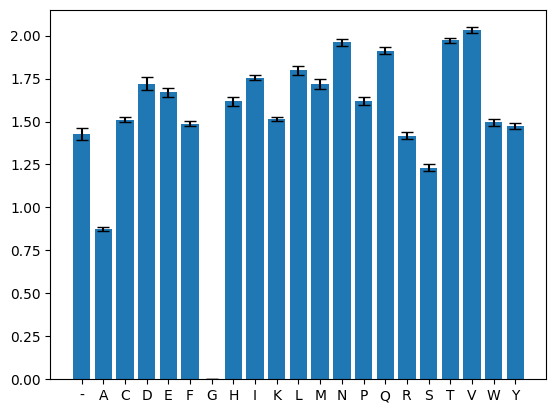

../models/SectorShuffling_SubAln1_Step00_noshuffle/SectorShuffling_SubAln1_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


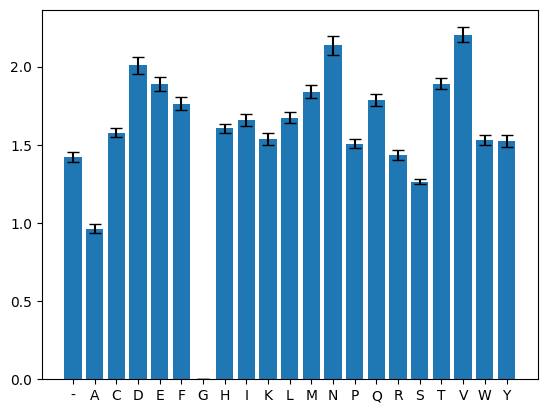

../models/SectorShuffling_SubAln2_Step00_noshuffle/SectorShuffling_SubAln2_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


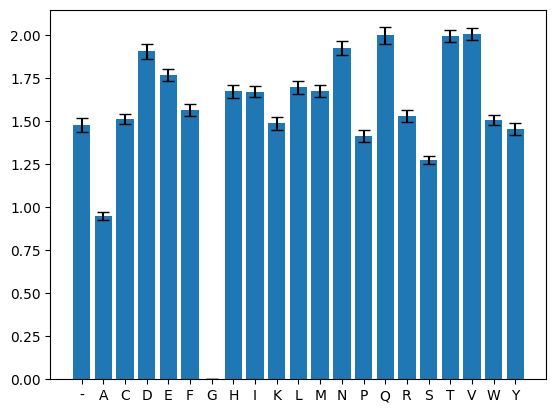

../models/SectorShuffling_SubAln3_Step00_noshuffle/SectorShuffling_SubAln3_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


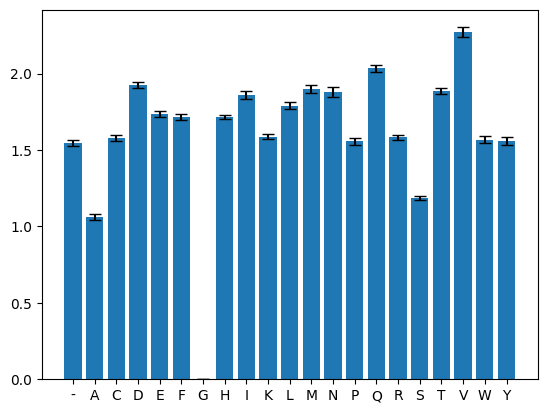

../models/SectorShuffling_SubAln4_Step00_noshuffle/SectorShuffling_SubAln4_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


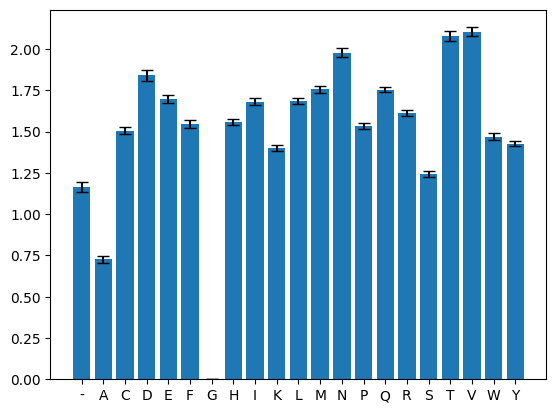

../models/SectorShuffling_SubAln5_Step00_noshuffle/SectorShuffling_SubAln5_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


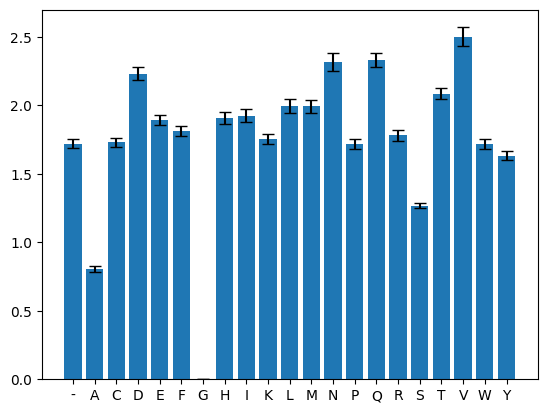

../models/SectorShuffling_SubAln6_Step00_noshuffle/SectorShuffling_SubAln6_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


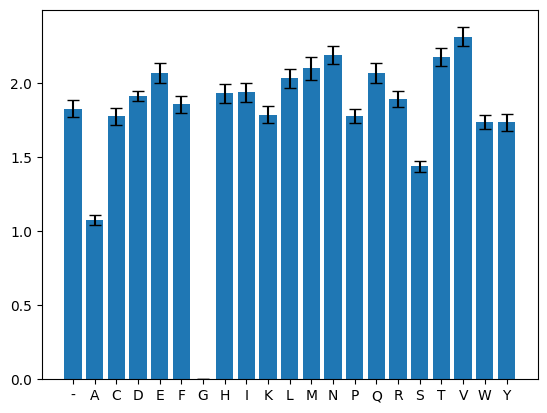

../models/SectorShuffling_SubAln7_Step00_noshuffle/SectorShuffling_SubAln7_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


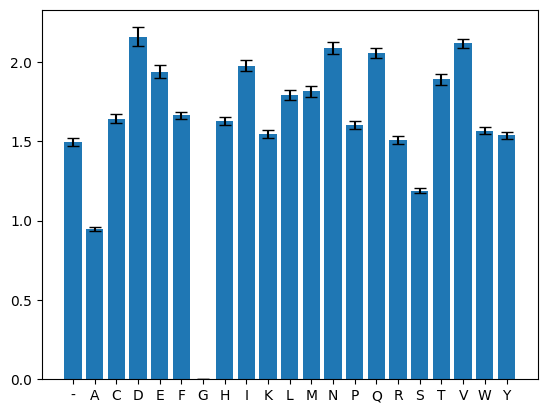

../models/SectorShuffling_SubAln8_Step00_noshuffle/SectorShuffling_SubAln8_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


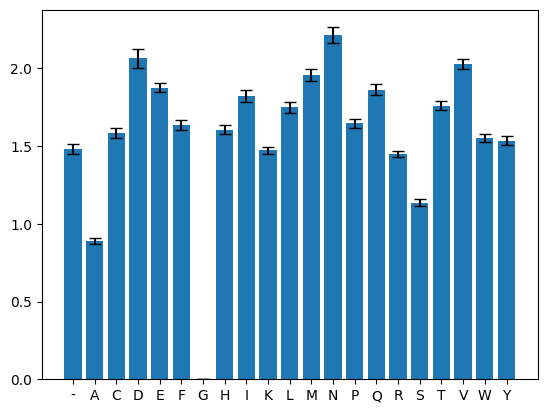

../models/SectorShuffling_SubAln9_Step00_noshuffle/SectorShuffling_SubAln9_Step00_noshuffle_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


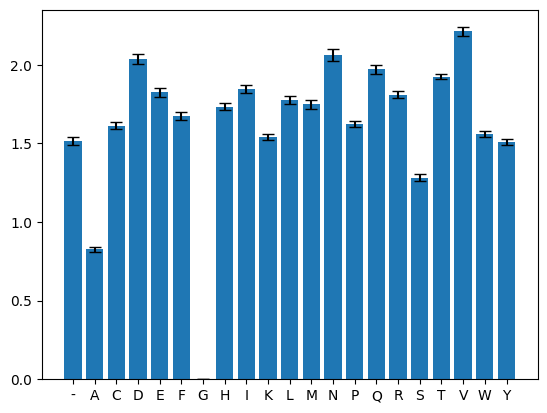

In [8]:
for f in df.loc[0, :].model_file:
    print(f)
    plt.figure()
    model = np.load(f, allow_pickle=True).item()
    Js_for_paramset = []
    for W_all in model["W_all"]:
        J, h = ut.Jw(W_all, q=21)
        Js_for_paramset.append(np.abs(compensatory_ddes(J).ravel()))
    plt.bar(
        np.arange(21),
        np.mean(Js_for_paramset, axis=0),
        yerr=np.std(Js_for_paramset, axis=0) / np.sqrt(10),
        capsize=4
    )
    plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
    plt.show()

In [9]:
df.index

MultiIndex([( 0, 0),
            ( 0, 1),
            ( 0, 2),
            ( 0, 3),
            ( 0, 4),
            ( 0, 5),
            ( 0, 6),
            ( 0, 7),
            ( 0, 8),
            ( 0, 9),
            (10, 0),
            (10, 1),
            (10, 2),
            (10, 3),
            (10, 4),
            (10, 5),
            (10, 6),
            (10, 7),
            (10, 8),
            (10, 9),
            (18, 0),
            (18, 1),
            (18, 2),
            (18, 3),
            (18, 4),
            (18, 5),
            (18, 6),
            (18, 7),
            (18, 8),
            (18, 9),
            (19, 0),
            (19, 1),
            (19, 2),
            (19, 3),
            (19, 4),
            (19, 5),
            (19, 6),
            (19, 7),
            (19, 8),
            (19, 9),
            (20, 0),
            (20, 1),
            (20, 2),
            (20, 3),
            (20, 4),
            (20, 5),
            (20, 6),
            (

../models/SectorShuffling_SubAln0_Step22_Col239/SectorShuffling_SubAln0_Step22_Col239_ModelSBM_N_chains256_N_iter1000_Param_initzero_k_MCMC10000_lambda_J0_lambda_h0_m1_theta0.15_N_Av10_R0.npy


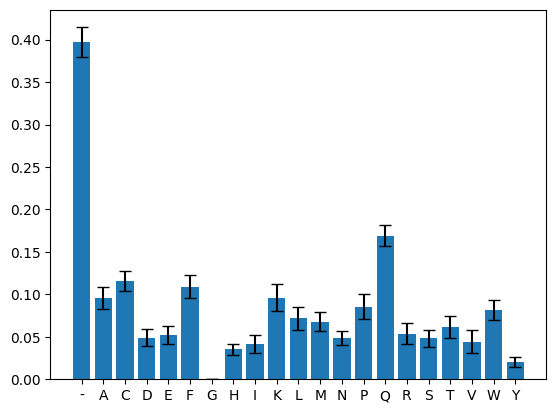

In [19]:
for f in df.loc[22, :].model_file:
    print(f)
    plt.figure()
    model = np.load(f, allow_pickle=True).item()
    Js_for_paramset = []
    for W_all in model["W_all"]:
        J, h = ut.Jw(W_all, q=21)
        Js_for_paramset.append(np.abs(compensatory_ddes(J).ravel()))
    plt.bar(
        np.arange(21),
        np.mean(Js_for_paramset, axis=0),
        yerr=np.std(Js_for_paramset, axis=0) / np.sqrt(10),
        capsize=4
    )
    plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
    plt.show()
    break